In [1]:
import torch
import torch.nn as nn
from torchvision.transforms import Compose
import cv2
import numpy as np


In [2]:
import torch
import xformers
print(f"Torch version: {torch.__version__}")
print(f"xFormers version: {xformers.__version__}")
print(f"Is CUDA available: {torch.cuda.is_available()}")

Torch version: 2.10.0+cu126
xFormers version: 0.0.35
Is CUDA available: True


In [3]:
import cv2
import torch
import sys

sys.path.insert(0, 'D:/Projects/Minor Project/Depth-Anything-V2/metric_depth')

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

from depth_anything_v2.dpt import DepthAnythingV2

model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]}
}

encoder = 'vits' # or 'vits', 'vitb'
dataset = 'hypersim' # 'hypersim' for indoor model, 'vkitti' for outdoor model
max_depth = 10 # 20 for indoor model, 80 for outdoor model

check_path = f'D:/Projects/Minor Project/Parameters/DA-Parameter/depth_anything_v2_metric_hypersim_{encoder}.pth'

model = DepthAnythingV2(**model_configs[encoder], max_depth=max_depth)
model.load_state_dict(torch.load(check_path, map_location='cpu'))
model = model.to(DEVICE).eval()

A matching Triton is not available, some optimizations will not be enabled
Traceback (most recent call last):
  File "d:\Projects\Minor Project\.venv\lib\site-packages\xformers\__init__.py", line 57, in _is_triton_available
    import triton  # noqa
ModuleNotFoundError: No module named 'triton'


In [ ]:
depth_norm = cv2.normalize(depth, None, 0, 255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# 2. Apply a colormap (COLORMAP_MAGMA or COLORMAP_INFERNO are popular for depth)
depth_color = cv2.applyColorMap(depth_norm, cv2.COLORMAP_MAGMA)

def resize_to_screen(image, max_width=1280):
    h, w = image.shape[:2]
    if w > max_width:
        ratio = max_width / float(w)
        new_dim = (max_width, int(h * ratio))
        return cv2.resize(image, new_dim, interpolation=cv2.INTER_AREA)
    return image

# Apply it before showing
display_img = resize_to_screen(depth_color)
cv2.imshow('Resized Depth Map', display_img)
cv2.waitKey(0)

In [ ]:
import open3d as o3d

# 1. Download and load a sample RGBD dataset
data = o3d.data.SampleRedwoodRGBDImages()
color_path = data.color_paths[0]
depth_path = data.depth_paths[0]

# 2. Read the images
color_raw = o3d.io.read_image(color_path)
depth_raw = o3d.io.read_image(depth_path)

# 3. Check pixel depth (Redwood is 16-bit unsigned short)
depth_array = np.asarray(depth_raw)
print(f"Depth Image Shape: {depth_array.shape}")
print(f"Data Type: {depth_array.dtype}")
print(f"Example Pixel Value (Depth in mm): {depth_array[240, 320]}")

# 4. Create RGBDImage and visualize
rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw, depth_raw, convert_rgb_to_intensity=False)

# This should open a window with two images
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1)
plt.title('Color Image')
plt.imshow(rgbd_image.color)
plt.subplot(1, 2, 2)
plt.title('Depth Image')
plt.imshow(rgbd_image.depth)
plt.show()

In [ ]:
# Assuming 'rgbd_image' is already created from the previous step

# 1. Define Camera Intrinsics 
# (Standard VGA parameters for the Redwood dataset)
pinhole_camera_intrinsic = o3d.camera.PinholeCameraIntrinsic(
    o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault)

# 2. Create PointCloud
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image, pinhole_camera_intrinsic)

# 3. Flip it (Open3D uses a right-handed coordinate system where Y is down)
pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])

# 4. Visualize the 3D result
o3d.visualization.draw_geometries([pcd])

In [4]:
import h5py

In [5]:
file_path = 'D:/Projects/Minor Project/Datasets/raw/NYU depth v2/nyu_depth_v2_labeled.mat'

with h5py.File(file_path, 'r') as f:
    images = np.array(f['images'])
    depths = np.array(f['depths'])
    labels = np.array(f['labels'])
    
    # Get class names
    names = []
    for ref in f['names'][0]:
        names.append(''.join(chr(c) for c in f[ref][:].flatten()))
    print(f"Total classes: {len(names)}")
    print(f"Classes: {names[:20]}")  # first 20

Total classes: 894
Classes: ['book', 'bottle', 'cabinet', 'ceiling', 'chair', 'cone', 'counter', 'dishwasher', 'faucet', 'fire extinguisher', 'floor', 'garbage bin', 'microwave', 'paper towel dispenser', 'paper', 'pot', 'refridgerator', 'stove burner', 'table', 'unknown']


In [22]:

# Pick a sample
idx = 15
img_final   = np.transpose(images[idx], (2, 1, 0))   # (480, 640, 3)
depth_final = np.transpose(depths[idx], (1, 0))       # (480, 640)
label_final = np.transpose(labels[idx], (1, 0))       # (480, 640)

print(f"Unique labels in this image: {np.unique(label_final)}")

Unique labels in this image: [ 0  3  4 11 19 21 30 62 66 67 85 87 88]


In [23]:
print(img_final.shape)
print(depth_final.shape)

(480, 640, 3)
(480, 640)


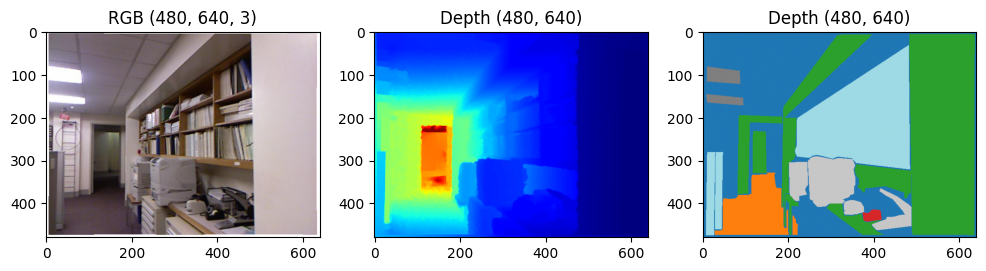

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(12, 5))

ax[0].imshow(img_final)
ax[0].set_title(f"RGB {img_final.shape}")

ax[1].imshow(depth_final, cmap='jet')
ax[1].set_title(f"Depth {depth_final.shape}")

ax[2].imshow(label_final, cmap='tab20')
ax[2].set_title(f"Depth {depth_final.shape}")

plt.show()

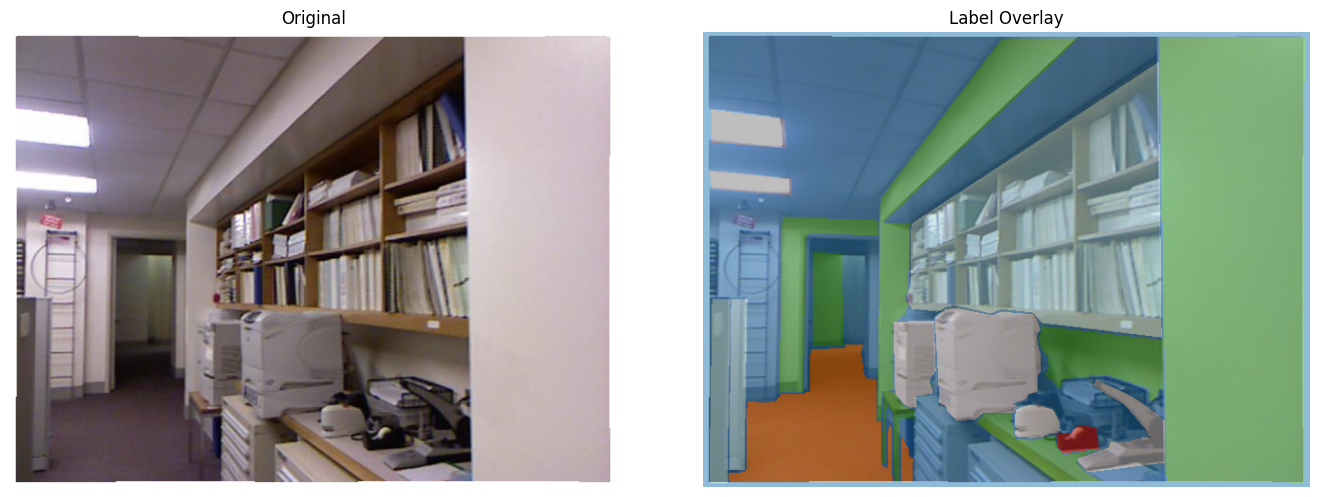

In [25]:
def visualize_label_overlay(img, label, alpha=0.5):
    # Generate random colors for each class
    num_classes = label.max() + 1
    colors = plt.cm.tab20(np.linspace(0, 1, num_classes))
    
    # Create colored label map
    colored_label = colors[label][:, :, :3]  # (480, 640, 3)
    colored_label = (colored_label * 255).astype(np.uint8)
    
    # Overlay
    overlay = (img * (1 - alpha) + colored_label * alpha).astype(np.uint8)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(img)
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    axes[1].imshow(overlay)
    axes[1].set_title('Label Overlay')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_label_overlay(img_final, label_final)

In [26]:
# test_image_path = cv2.imread('D:/Projects/Minor Project/Datasets/raw/testings_images/nice1.jpg')
# img_final = cv2.cvtColor(test_image_path, cv2.COLOR_BGR2RGB)
depth = model.infer_image(img_final)

In [27]:
print(depth.shape)
print(depth_final.shape)

(480, 640)
(480, 640)


In [28]:
print(depth)
print()
print(depth_final)

[[0.92865413 0.8590393  0.85418093 ... 0.70555437 0.7200892  0.7284583 ]
 [0.86020327 0.8040594  0.86072004 ... 0.70613533 0.7182082  0.68196964]
 [0.83551925 0.8006344  0.8356401  ... 0.6939642  0.69409823 0.6778176 ]
 ...
 [0.68884623 0.62971014 0.6711686  ... 0.6372541  0.6552362  0.6807904 ]
 [0.7091144  0.6185271  0.69565785 ... 0.64012367 0.66122204 0.6686779 ]
 [0.74638915 0.7704529  0.7103298  ... 0.6812422  0.67216533 0.7087295 ]]

[[2.7549703  2.754563   2.753541   ... 1.0285996  1.0283742  1.0282844 ]
 [2.7553763  2.7549717  2.7539554  ... 1.0285078  1.028284   1.028195  ]
 [2.7563863  2.7559903  2.7549915  ... 1.0282785  1.0280596  1.0279728 ]
 ...
 [3.6270914  3.6267648  3.6259353  ... 0.9893698  0.9891676  0.9890878 ]
 [3.626246   3.625907   3.6250517  ... 0.9895933  0.989381   0.9892971 ]
 [3.6259048  3.6255617  3.624699   ... 0.98968333 0.9894673  0.9893818 ]]


In [29]:
def align_depth(pred, gt, mask=None):
    """
    Least-squares scale and shift alignment
    pred, gt: [H, W] numpy arrays
    mask: valid pixel mask (optional, exclude 0/invalid GT pixels)
    """
    if mask is None:
        mask = gt > 0  # exclude invalid GT pixels

    pred_valid = pred[mask].flatten()
    gt_valid   = gt[mask].flatten()

    # Solve: gt ≈ scale * pred + shift
    A = np.stack([pred_valid, np.ones_like(pred_valid)], axis=1)  # [N, 2]
    result = np.linalg.lstsq(A, gt_valid, rcond=None)
    scale, shift = result[0]

    pred_aligned = scale * pred + shift
    return pred_aligned, scale, shift

# Align
pred_aligned, scale, shift = align_depth(depth, depth_final)

In [30]:
print(pred_aligned)
print()
print(depth_final)

[[1.566611  1.4647473 1.4576384 ... 1.2401608 1.261429  1.273675 ]
 [1.4664505 1.3842981 1.4672067 ... 1.241011  1.2586765 1.2056506]
 [1.4303317 1.3792865 1.4305085 ... 1.2232015 1.2233977 1.1995751]
 ...
 [1.2157128 1.129182  1.189846  ... 1.1402206 1.1665329 1.203925 ]
 [1.24537   1.1128184 1.2256798 ... 1.1444196 1.1752917 1.1862015]
 [1.2999122 1.3351235 1.2471485 ... 1.2045861 1.1913044 1.2448069]]

[[2.7549703  2.754563   2.753541   ... 1.0285996  1.0283742  1.0282844 ]
 [2.7553763  2.7549717  2.7539554  ... 1.0285078  1.028284   1.028195  ]
 [2.7563863  2.7559903  2.7549915  ... 1.0282785  1.0280596  1.0279728 ]
 ...
 [3.6270914  3.6267648  3.6259353  ... 0.9893698  0.9891676  0.9890878 ]
 [3.626246   3.625907   3.6250517  ... 0.9895933  0.989381   0.9892971 ]
 [3.6259048  3.6255617  3.624699   ... 0.98968333 0.9894673  0.9893818 ]]


Text(0.5, 1.0, 'Scaled depth (480, 640)')

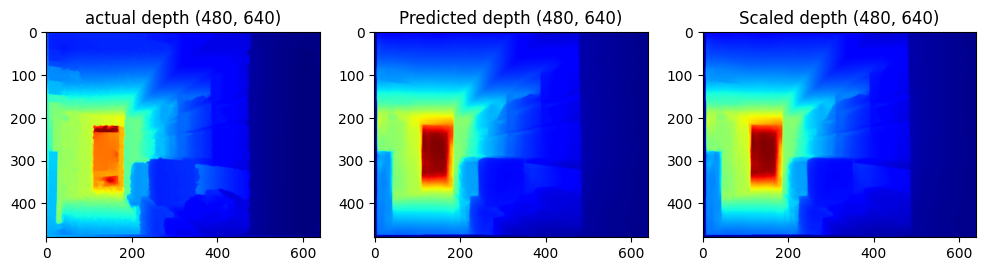

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))

ax[0].imshow(depth_final, cmap='jet')
ax[0].set_title(f"actual depth {depth_final.shape}")

ax[1].imshow(depth, cmap='jet')
ax[1].set_title(f"Predicted depth {depth.shape}")


ax[2].imshow(pred_aligned, cmap='jet')
ax[2].set_title(f"Scaled depth {pred_aligned.shape}")

In [32]:
import open3d as o3d

fx, fy = 518.8579, 519.4696
cx, cy = 325.5824, 253.7362
width, height = 640, 480

# Create the Intrinsic object
intrinsic = o3d.camera.PinholeCameraIntrinsic(width, height, fx, fy, cx, cy)

In [33]:
# Assuming img_final and depth_final are your processed NumPy arrays
# img_final: (480, 640, 3) uint8
# depth_final: (480, 640) float32 (meters)
# Both should be (480, 640, 3) and (480, 640) respectively.

img_contiguous = np.ascontiguousarray(img_final.astype(np.uint8))
depth_contiguous = np.ascontiguousarray(pred_aligned.astype(np.float32))

# Now Open3D will accept them
color_raw = o3d.geometry.Image(img_contiguous)
depth_raw = o3d.geometry.Image(depth_contiguous)

print(f"Color: {np.asarray(color_raw).shape}")
print(f"Depth: {np.asarray(depth_raw).shape}")

# Create RGBD Image
# depth_trunc=10.0 ignores objects further than 10 meters
# convert_rgb_to_intensity=False keeps the colors for the point cloud
rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw, 
    depth_raw, 
    depth_scale=1.0,    # 1.0 because NYU is already in meters
    depth_trunc=10.0,   # Increase this if your room is very deep
    convert_rgb_to_intensity=False
)

# Generate Point Cloud
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image, 
    intrinsic
)

# Flip it: NYU coordinates are often inverted compared to Open3D's visualizer
pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])

# Visualize
o3d.visualization.draw_geometries([pcd])

Color: (480, 640, 3)
Depth: (480, 640)


In [ ]:
depth_resized = cv2.resize(depth, (depth_final.shape[1], depth_final.shape[0]))
error = np.abs(depth_resized - depth_final)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im1 = axes[0].imshow(depth_final, cmap='plasma', vmin=0, vmax=10)
axes[0].set_title('Ground Truth')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(depth_resized, cmap='plasma', vmin=0, vmax=10)
axes[1].set_title('Predicted')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(error, cmap='Reds')
axes[2].set_title('Absolute Error')
axes[2].axis('off')
plt.colorbar(im3, ax=axes[2], label='error (meters)')

plt.tight_layout()
plt.show()

In [ ]:
vit_encoder = model.pretrained
print(vit_encoder)

In [ ]:
# test_image_path = cv2.imread('D:/Projects/Minor Project/Datasets/raw/testings_images/nice1.jpg')
# img_final = cv2.cvtColor(test_image_path, cv2.COLOR_BGR2RGB)

In [ ]:
def get_depth_encoder_features(depth_model, raw_img_np):
    features = {}
    input_size = {}

    def hook(module, input, output):
        features['out'] = output

    handle = depth_model.pretrained.blocks[-1].register_forward_hook(hook)

    with torch.no_grad():
        # Get the tensor to know exact H, W after preprocessing
        image, (h, w) = depth_model.image2tensor(raw_img_np, input_size=518)
        input_size['h'] = image.shape[2] // 14  # patch size is 14
        input_size['w'] = image.shape[3] // 14
        depth_model.forward(image.to(DEVICE))

    handle.remove()

    enc = features['out'][:, 1:, :]  # remove CLS token
    B, N, C = enc.shape
    
    pH = input_size['h']  # actual patch height
    pW = input_size['w']  # actual patch width
    
    print(f"Patch grid: {pH}x{pW}={pH*pW}, N={N}")  # should match

    spatial_map = enc.reshape(B, pH, pW, C).permute(0, 3, 1, 2)  # [1, 384, pH, pW]
    return spatial_map

depth_features = get_depth_encoder_features(model, img_final)
print(f"Shape: {depth_features.shape}")  # e.g. [1, 384, 37, 49] for non-square